## PTID-AI-MAR-26-1134_PRAICP-1002-TrafSignDetc

#### Import Libraries

In [59]:
import csv, random
from pathlib import Path
from typing import Dict, List
from tqdm import tqdm

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from PIL import Image, ImageDraw
import math

In [2]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn

from torchvision.transforms import functional as TF
from PIL import Image, ImageOps, ImageEnhance
import torch.utils.data

In [3]:
# Print total labels / classes
rows = list(csv.DictReader(open("/kaggle/input/datasets/bharaniamarnath/traffic-signs-dataset/Train.csv", newline="")))
max_label = max(int(r["ClassId"]) for r in rows)
print(max_label)

42


In [4]:
# Configurations
DATA_ROOT = Path("/kaggle/input/datasets/bharaniamarnath/traffic-signs-dataset")            # dataset root containing Train/, Meta/, Test/ and CSVs
TRAIN_CSV = DATA_ROOT / "Train.csv"
NUM_CLASSES = max_label + 1  # if ClassId already uses 0 as background, else +2 below
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 2
NUM_EPOCHS = 16
LR = 5e-4
OUTPUT_DIR = Path("outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

### Data Analysis

In [60]:
# Load and augment dataframe
def eda_load_df(csv_path=TRAIN_CSV):
    df = pd.read_csv(csv_path)
    for c in ["Roi.X1","Roi.Y1","Roi.X2","Roi.Y2","ClassId"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["width"] = df["Roi.X2"] - df["Roi.X1"]
    df["height"] = df["Roi.Y2"] - df["Roi.Y1"]
    df["area"] = df["width"] * df["height"]
    df["aspect"] = df["width"] / df["height"].replace(0, np.nan)
    return df

In [61]:
eda_df = eda_load_df()
print("Total annotations:", len(eda_df))
print("Unique images:", eda_df["Path"].nunique())
print("Unique classes:", eda_df["ClassId"].nunique())
eda_df[["width","height","area","aspect"]].describe().T

Total annotations: 39209
Unique images: 39209
Unique classes: 43


,count,mean,std,min,25%,50%,75%,max
width,39209.0,39.197786,21.821369,15.000000,24.000000,33.0,47.000000,203.0000
height,39209.0,38.765998,20.828697,15.000000,24.000000,32.0,47.000000,185.0000
area,39209.0,1966.080288,2584.386846,225.000000,576.000000,1056.0,2209.000000,37555.0000
aspect,39209.0,1.008278,0.084328,0.333333,0.965517,1.0,1.052632,1.4375


### Data Visualization

In [66]:
# Class distribution (top K) and cumulative coverage
def plot_class_distribution(eda_df, top_k=30, figsize=(12,4)):
    counts = eda_df["ClassId"].value_counts().sort_values(ascending=False)
    top = counts.head(top_k)
    plt.figure(figsize=figsize)
    sns.barplot(x=top.index.astype(int).astype(str), y=top.values, palette="viridis")
    plt.xlabel("ClassId"); plt.ylabel("Annotation count"); plt.title(f"Top {top_k} classes by annotation count")
    plt.xticks(rotation=90)
    plt.tight_layout()

In [67]:
    
def plot_class_cumsum(eda_df, figsize=(8,3)):
    counts = eda_df["ClassId"].value_counts().sort_values(ascending=False)
    cumsum = counts.cumsum() / counts.sum()
    plt.figure(figsize=figsize)
    plt.plot(cumsum.values, marker='o', markersize=3)
    plt.grid(True)
    plt.xlabel("Classes sorted by freq"); plt.ylabel("Cumulative proportion")
    plt.title("Class frequency cumulative coverage")
    plt.tight_layout()

/tmp/ipykernel_56/4225394183.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.index.astype(int).astype(str), y=top.values, palette="viridis")


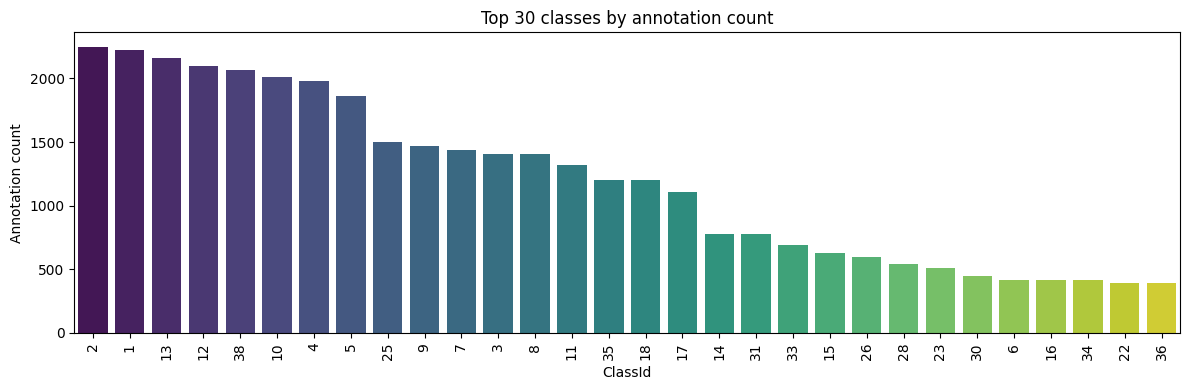

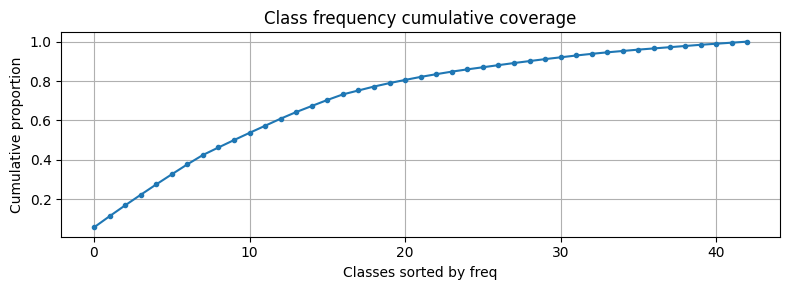

In [68]:
plot_class_distribution(eda_df, top_k=30)
plt.show()
plot_class_cumsum(eda_df)
plt.show()

In [70]:
# Size, aspect, area distributions and aspect vs area scatter (sampled)
def plot_size_distributions(eda_df, figsize=(12,3)):
    plt.figure(figsize=figsize)
    plt.subplot(1,3,1); sns.histplot(eda_df["width"], bins=50); plt.title("Width")
    plt.subplot(1,3,2); sns.histplot(eda_df["height"], bins=50); plt.title("Height")
    plt.subplot(1,3,3); sns.histplot(eda_df["area"], bins=50); plt.title("Area")
    plt.tight_layout()

In [71]:
def plot_aspect_vs_area(eda_df, sample_n=2000, figsize=(6,5)):
    sample = eda_df.sample(min(len(eda_df), sample_n), random_state=0)
    plt.figure(figsize=figsize)
    plt.scatter(sample["aspect"], sample["area"], alpha=0.4, s=6)
    plt.xscale('symlog'); plt.yscale('log')
    plt.xlabel("Aspect ratio (w/h)"); plt.ylabel("Area"); plt.title("Aspect vs Area (sample)")
    plt.tight_layout()

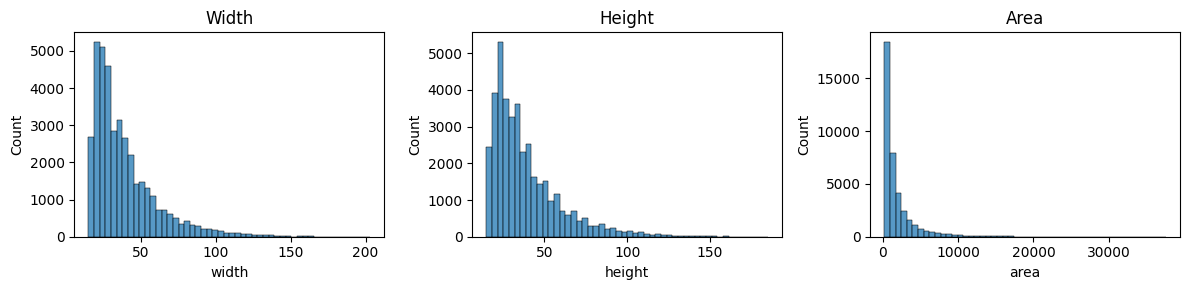

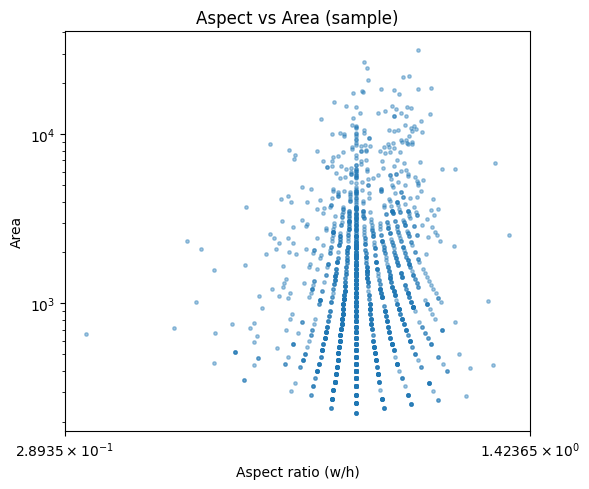

In [72]:
plot_size_distributions(eda_df)
plt.show()
plot_aspect_vs_area(eda_df)
plt.show()

### Data Preprocessing

In [5]:
def read_csv_rows(path: Path) -> List[Dict[str,str]]:
    with path.open(newline='') as f:
        return list(csv.DictReader(f))

In [6]:
def parse_rows(rows: List[Dict[str,str]]) -> Dict[str, List[Dict]]:
    anns = {}
    for r in rows:
        img_path = r["Path"]  # e.g., "Train/20/00020_0000_0000.png"
        x1 = float(r["Roi.X1"]); y1 = float(r["Roi.Y1"])
        x2 = float(r["Roi.X2"]); y2 = float(r["Roi.Y2"])
        cls = int(r["ClassId"])
        anns[img_path] = anns.get(img_path, []) + [{"bbox":[x1,y1,x2,y2], "category_id": cls}]
    return anns

In [7]:
class TrafficSignDataset(torch.utils.data.Dataset):
    def __init__(self, data_root: Path, train_csv: Path, transforms=None):
        self.data_root = data_root
        rows = read_csv_rows(train_csv)
        self.anns = parse_rows(rows)
        self.files = sorted(self.anns.keys())
        self.transforms = transforms

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        rel_path = self.files[idx]               # e.g., "Train/20/00020_0000_0000.png"
        img_path = self.data_root / rel_path     # resolves correctly
        if not img_path.exists():
            # fallback to basename inside Train folder
            img_path = self.data_root / "Train" / Path(rel_path).name
        img = Image.open(img_path).convert("RGB")
        img = preprocess_image(img)

        ann_list = self.anns[rel_path]
        boxes, labels, areas, iscrowd = [], [], [], []
        for a in ann_list:
            x1,y1,x2,y2 = a["bbox"]
            boxes.append([x1,y1,x2,y2]); labels.append(a["category_id"])
            areas.append((x2-x1)*(y2-y1)); iscrowd.append(0)

        if len(boxes)==0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx]),
                  "area": areas, "iscrowd": iscrowd}
        if self.transforms:
            img, target = self.transforms(img, target)
        img = TF.to_tensor(img)
        return img, target

In [8]:
def preprocess_image(img: Image.Image, short_side:int=400, max_side:int=1000) -> Image.Image:
    w,h = img.size
    short = min(w,h); scale = short_side/short
    if max(w,h)*scale > max_side: scale = max_side/max(w,h)
    img = img.resize((int(round(w*scale)), int(round(h*scale))), Image.BILINEAR)
    ycbcr = img.convert("YCbCr"); y,cb,cr = ycbcr.split()
    y = ImageOps.equalize(y)
    img = Image.merge("YCbCr",(y,cb,cr)).convert("RGB")
    img = ImageEnhance.Color(img).enhance(1.05)
    return img

In [9]:
import random
class TrainTransforms:
    def __init__(self, flip_prob=0.5, brightness=0.2):
        self.flip_prob = flip_prob; self.brightness = brightness
    def __call__(self, image: Image.Image, target: dict):
        if random.random() < self.flip_prob:
            image = ImageOps.mirror(image)
            w,_ = image.size
            if target["boxes"].numel()>0:
                boxes = target["boxes"].clone(); boxes[:,[0,2]] = w - boxes[:,[2,0]]; target["boxes"]=boxes
        factor = 1.0 + random.uniform(-self.brightness, self.brightness)
        image = ImageEnhance.Brightness(image).enhance(factor)
        return image, target

### Model Building

In [10]:
def get_model(num_classes:int):
    # pretrained backbone + FPN, smaller and faster than resnet50
    model = fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)
    return model

In [11]:
def collate_fn(batch): return tuple(zip(*batch))

In [12]:
def stratified_subset_indices(dataset, frac=0.3, seed=42):
    rng = np.random.RandomState(seed)
    cls_to_idxs = defaultdict(list)
    for i in range(len(dataset)):
        _, target = dataset[i]
        labels = target["labels"].cpu().numpy() if isinstance(target["labels"], torch.Tensor) else np.array(target["labels"])
        unique = np.unique(labels) if labels.size else np.array([-1])
        for c in unique:
            cls_to_idxs[int(c)].append(i)
    selected = set()
    for cls, idxs in cls_to_idxs.items():
        if cls == -1: continue
        k = max(1, int(len(idxs) * frac))
        chosen = rng.choice(idxs, size=k, replace=False)
        selected.update(chosen.tolist())
    target_n = int(len(dataset) * frac)
    if len(selected) < target_n:
        remaining = list(set(range(len(dataset))) - selected)
        add = rng.choice(remaining, size=(target_n - len(selected)), replace=False)
        selected.update(add.tolist())
    return sorted(selected)

### Model Training + Evaluation

In [13]:
def train(resume_from: str = None, new_num_epochs: int = None):
    ds = TrafficSignDataset(DATA_ROOT, TRAIN_CSV, transforms=TrainTransforms())
    # create a small stratified training subset for fast iteration
    subset_frac = 0.3   # use 30% of data for quick runs; change as needed
    train_idxs = stratified_subset_indices(ds, frac=subset_frac, seed=0)
    
    # keep a separate validation set (use a fixed small val set from remaining data)
    all_idxs = set(range(len(ds)))
    remaining = sorted(list(all_idxs - set(train_idxs)))
    val_count = max(500, int(0.05 * len(ds)))   # e.g., 500 images or 5% as val
    val_idxs = remaining[:val_count]
    
    train_ds = torch.utils.data.Subset(ds, train_idxs)
    val_ds = torch.utils.data.Subset(ds, val_idxs)

    
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, 
                                               num_workers=0, collate_fn=collate_fn)
    model = get_model(NUM_CLASSES).to(DEVICE)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.1)

    # resume support
    start_epoch = 0
    if resume_from:
        state = torch.load(Path(resume_from), map_location=DEVICE)
        model = get_model(NUM_CLASSES).to(DEVICE)
        model.load_state_dict(state)
        # recreate optimizer/scheduler/scaler
        params = [p for p in model.parameters() if p.requires_grad]
        opt = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.1)
        from torch.cuda.amp import GradScaler
        scaler = GradScaler()
        start_epoch = int(Path(resume_from).stem.split("_")[-1])  # assumes model_epoch_8.pth naming
        if new_num_epochs is not None:
            global NUM_EPOCHS
            NUM_EPOCHS = new_num_epochs
    else:
        model = get_model(NUM_CLASSES).to(DEVICE)
        params = [p for p in model.parameters() if p.requires_grad]
        opt = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.1)
        from torch.cuda.amp import GradScaler
        scaler = GradScaler()


    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", unit="batch")
        for images, targets in pbar:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
    
            opt.zero_grad()
            losses.backward()
            opt.step()
    
            epoch_loss += losses.item()
            # update progress bar with current loss and lr
            curr_lr = opt.param_groups[0]['lr']
            pbar.set_postfix(loss=f"{losses.item():.4f}", avg_loss=f"{epoch_loss / max(1, len(train_loader)):.4f}", lr=f"{curr_lr:.1e}")
        sched.step()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} avg_loss: {epoch_loss / max(1,len(train_loader)):.4f}")
        torch.save(model.state_dict(), OUTPUT_DIR/f"model_epoch_{epoch+1}.pth")

### Model Prediction

In [14]:
def inference(model_path: Path, rel_image_path: str, conf_thresh:float=0.5):
    model = get_model(NUM_CLASSES); model.load_state_dict(torch.load(model_path, map_location=DEVICE)); model.to(DEVICE).eval()
    img_path = DATA_ROOT / rel_image_path
    if not img_path.exists(): img_path = DATA_ROOT / "Train" / Path(rel_image_path).name
    img = Image.open(img_path).convert("RGB"); proc = preprocess_image(img)
    tensor = TF.to_tensor(proc).to(DEVICE)
    with torch.no_grad():
        out = model([tensor])[0]
    res=[]
    for b,s,l in zip(out["boxes"].cpu().numpy(), out["scores"].cpu().numpy(), out["labels"].cpu().numpy()):
        if s<conf_thresh: continue
        x1,y1,x2,y2 = b.tolist(); res.append({"bbox":[x1,y1,x2-x1,y2-y1],"score":float(s),"label":int(l)})
    return res

### Model Execution

In [15]:
if __name__=="__main__":
    train()
    # Run below def to resume from specific saved epochs
    # train(resume_from="outputs/model_epoch_8.pth", new_num_epochs=16)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 153MB/s] 
/tmp/ipykernel_56/1799714268.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/16: 100%|██████████| 5881/5881 [08:27<00:00, 11.58batch/s, avg_loss=1.1876, loss=0.8669, lr=5.0e-04]


Epoch 1/16 avg_loss: 1.1876


Epoch 2/16: 100%|██████████| 5881/5881 [08:18<00:00, 11.79batch/s, avg_loss=1.3926, loss=1.3872, lr=5.0e-04]


...

Epoch 14/16 avg_loss: 0.5405


Epoch 15/16: 100%|██████████| 5881/5881 [08:04<00:00, 12.15batch/s, avg_loss=0.5298, loss=0.9908, lr=5.0e-05]


Epoch 15/16 avg_loss: 0.5298


Epoch 16/16: 100%|██████████| 5881/5881 [08:04<00:00, 12.13batch/s, avg_loss=0.5192, loss=0.4789, lr=5.0e-05]


Epoch 16/16 avg_loss: 0.5192


### Test Model Prediction

In [50]:
pred_img = "/kaggle/input/datasets/bharaniamarnath/traffic-signs-dataset/Train/10/00010_00000_00005.png"
pred_mod_ep = "model_epoch_8.pth"
pred_res = inference(OUTPUT_DIR/pred_mod_ep, pred_img, 0.5)
print(pred_res)

[{'bbox': [6.927239418029785, 5.2233476638793945, 21.238478660583496, 22.74092388153076], 'score': 0.8488683700561523, 'label': 10}]


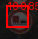

In [51]:
from PIL import Image, ImageDraw
from IPython.display import display

img = Image.open(pred_img).convert("RGB")
draw = ImageDraw.Draw(img)
for r in pred_res:
    x,y,w,h = r["bbox"]
    draw.rectangle([x,y,x+w,y+h], outline="red", width=2)
    draw.text((x, max(0,y-10)), f"{r['label']} {r['score']:.2f}", fill="red")
display(img)